# Data Visualization for Curb

In [ ]:
# Author: Ziyi Liu
# Project: Bachelor's Thesis - Cyclist Curb Detection under Varying Road Roughness
# Institution: Universität Kassel
# License: GNU General Public License v3.0

%load_ext autoreload
%autoreload 2

In [2]:
import sys
import pandas as pd  
import matplotlib.pyplot as plt
sys.path.append('../../')   # Add parent directory to Python path
from utils.visualization import *

Curb Dataset: Lab Dataset with ideal Labels<br>
a. curb 1cm<br>
b. curb 2cm<br>
c. curb 3cm<br>
d. ramp 0cm to 3cm<br>
e. transition stone 0cm to 3cm<br>
P3,P6,P11,P12,P18,P21

## 1. data explore

In [3]:
df= pd.read_csv('../../data/Curb/P3/handlebar/Accelerometer/Accelerometer_data_merged_ESP1.csv')  
df

,Unnamed: 0,NTP,Acc-X,Acc-Y,Acc-Z,Timestamp_unix,curb_activity,curb_scene,curb_height_down,curb_height_up,curb_type_down,curb_type_up,roughness
0,0,2024-07-29 13:51:06.990,5.094864,3.275269,9.126694,1.722261e+12,1.0,0.0,1.0,3.0,1.0,2.0,-1.0
1,1,2024-07-29 13:51:07.003,3.260910,2.413361,8.097183,1.722261e+12,1.0,0.0,1.0,3.0,1.0,2.0,-1.0
2,2,2024-07-29 13:51:07.005,3.160339,3.251327,8.724472,1.722261e+12,1.0,0.0,1.0,3.0,1.0,2.0,-1.0
3,3,2024-07-29 13:51:07.006,4.654327,3.246536,7.354980,1.722261e+12,1.0,0.0,1.0,3.0,1.0,2.0,-1.0
4,4,2024-07-29 13:51:07.008,3.045425,2.418137,8.595184,1.722261e+12,1.0,0.0,1.0,3.0,1.0,2.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
997336,997336,2024-07-29 15:13:35.185,1.618485,4.314346,8.552093,1.722266e+12,0.0,0.0,3.0,1.0,2.0,1.0,0.0
997337,997337,2024-07-29 15:13:35.190,1.690308,4.252106,8.729263,1.722266e+12,0.0,0.0,3.0,1.0,2.0,1.0,0.0
997338,997338,2024-07-29 15:13:35.195,1.666367,4.271255,8.676590,1.722266e+12,0.0,0.0,3.0,1.0,2.0,1.0,0.0
997339,997339,2024-07-29 15:13:35.202,1.637634,4.357452,8.489838,1.722266e+12,0.0,0.0,3.0,1.0,2.0,1.0,0.0


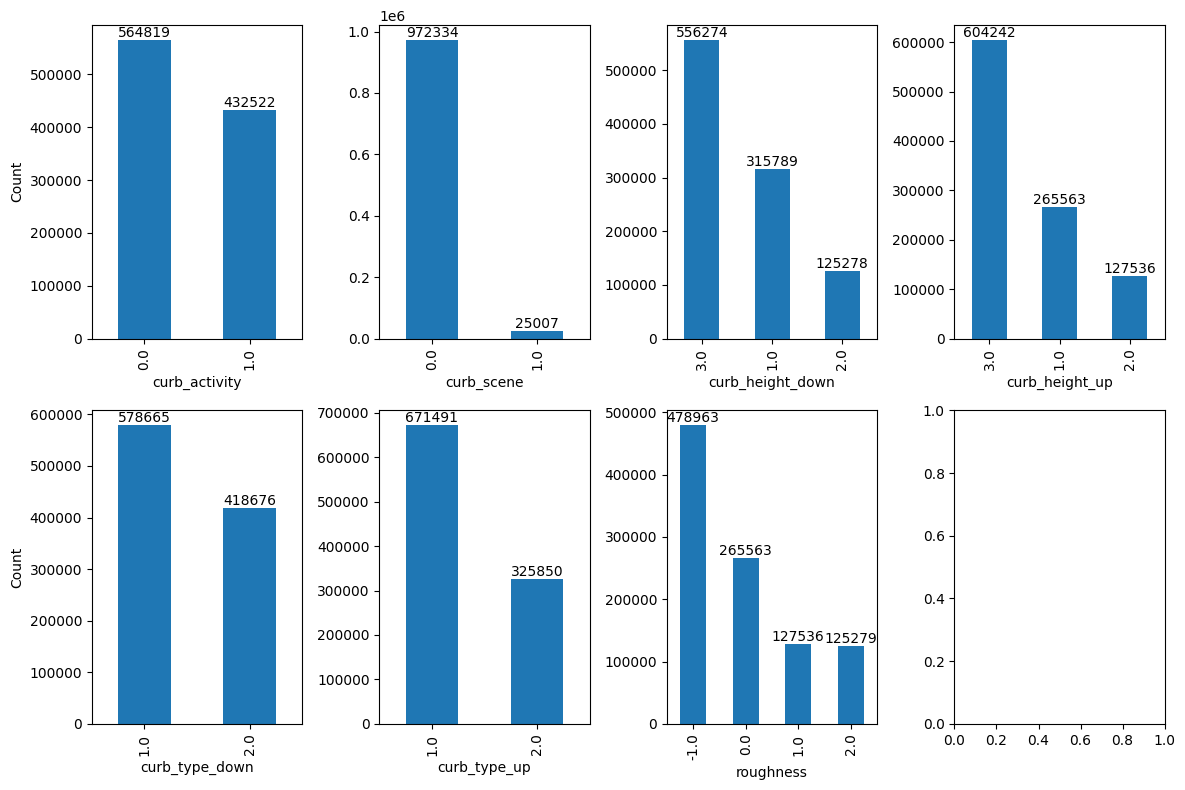

In [4]:
# Show unique values for each attribute in df_one
attributes = [
    'curb_activity',
    'curb_scene',
    'curb_height_down',
    'curb_height_up',
    'curb_type_down',
    'curb_type_up',
    'roughness'
 ]
fig, axes = plt.subplots(2, 4, figsize=(12, 8))
axes = axes.flatten()
axes[0].set_ylabel('Count')
axes[4].set_ylabel('Count')

for i, attr in enumerate(attributes):
    counts = df[attr].value_counts()
    counts.plot(kind='bar', ax=axes[i])
    axes[i].set_xlabel(attr)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

Sampling frequency: 201.08 Hz


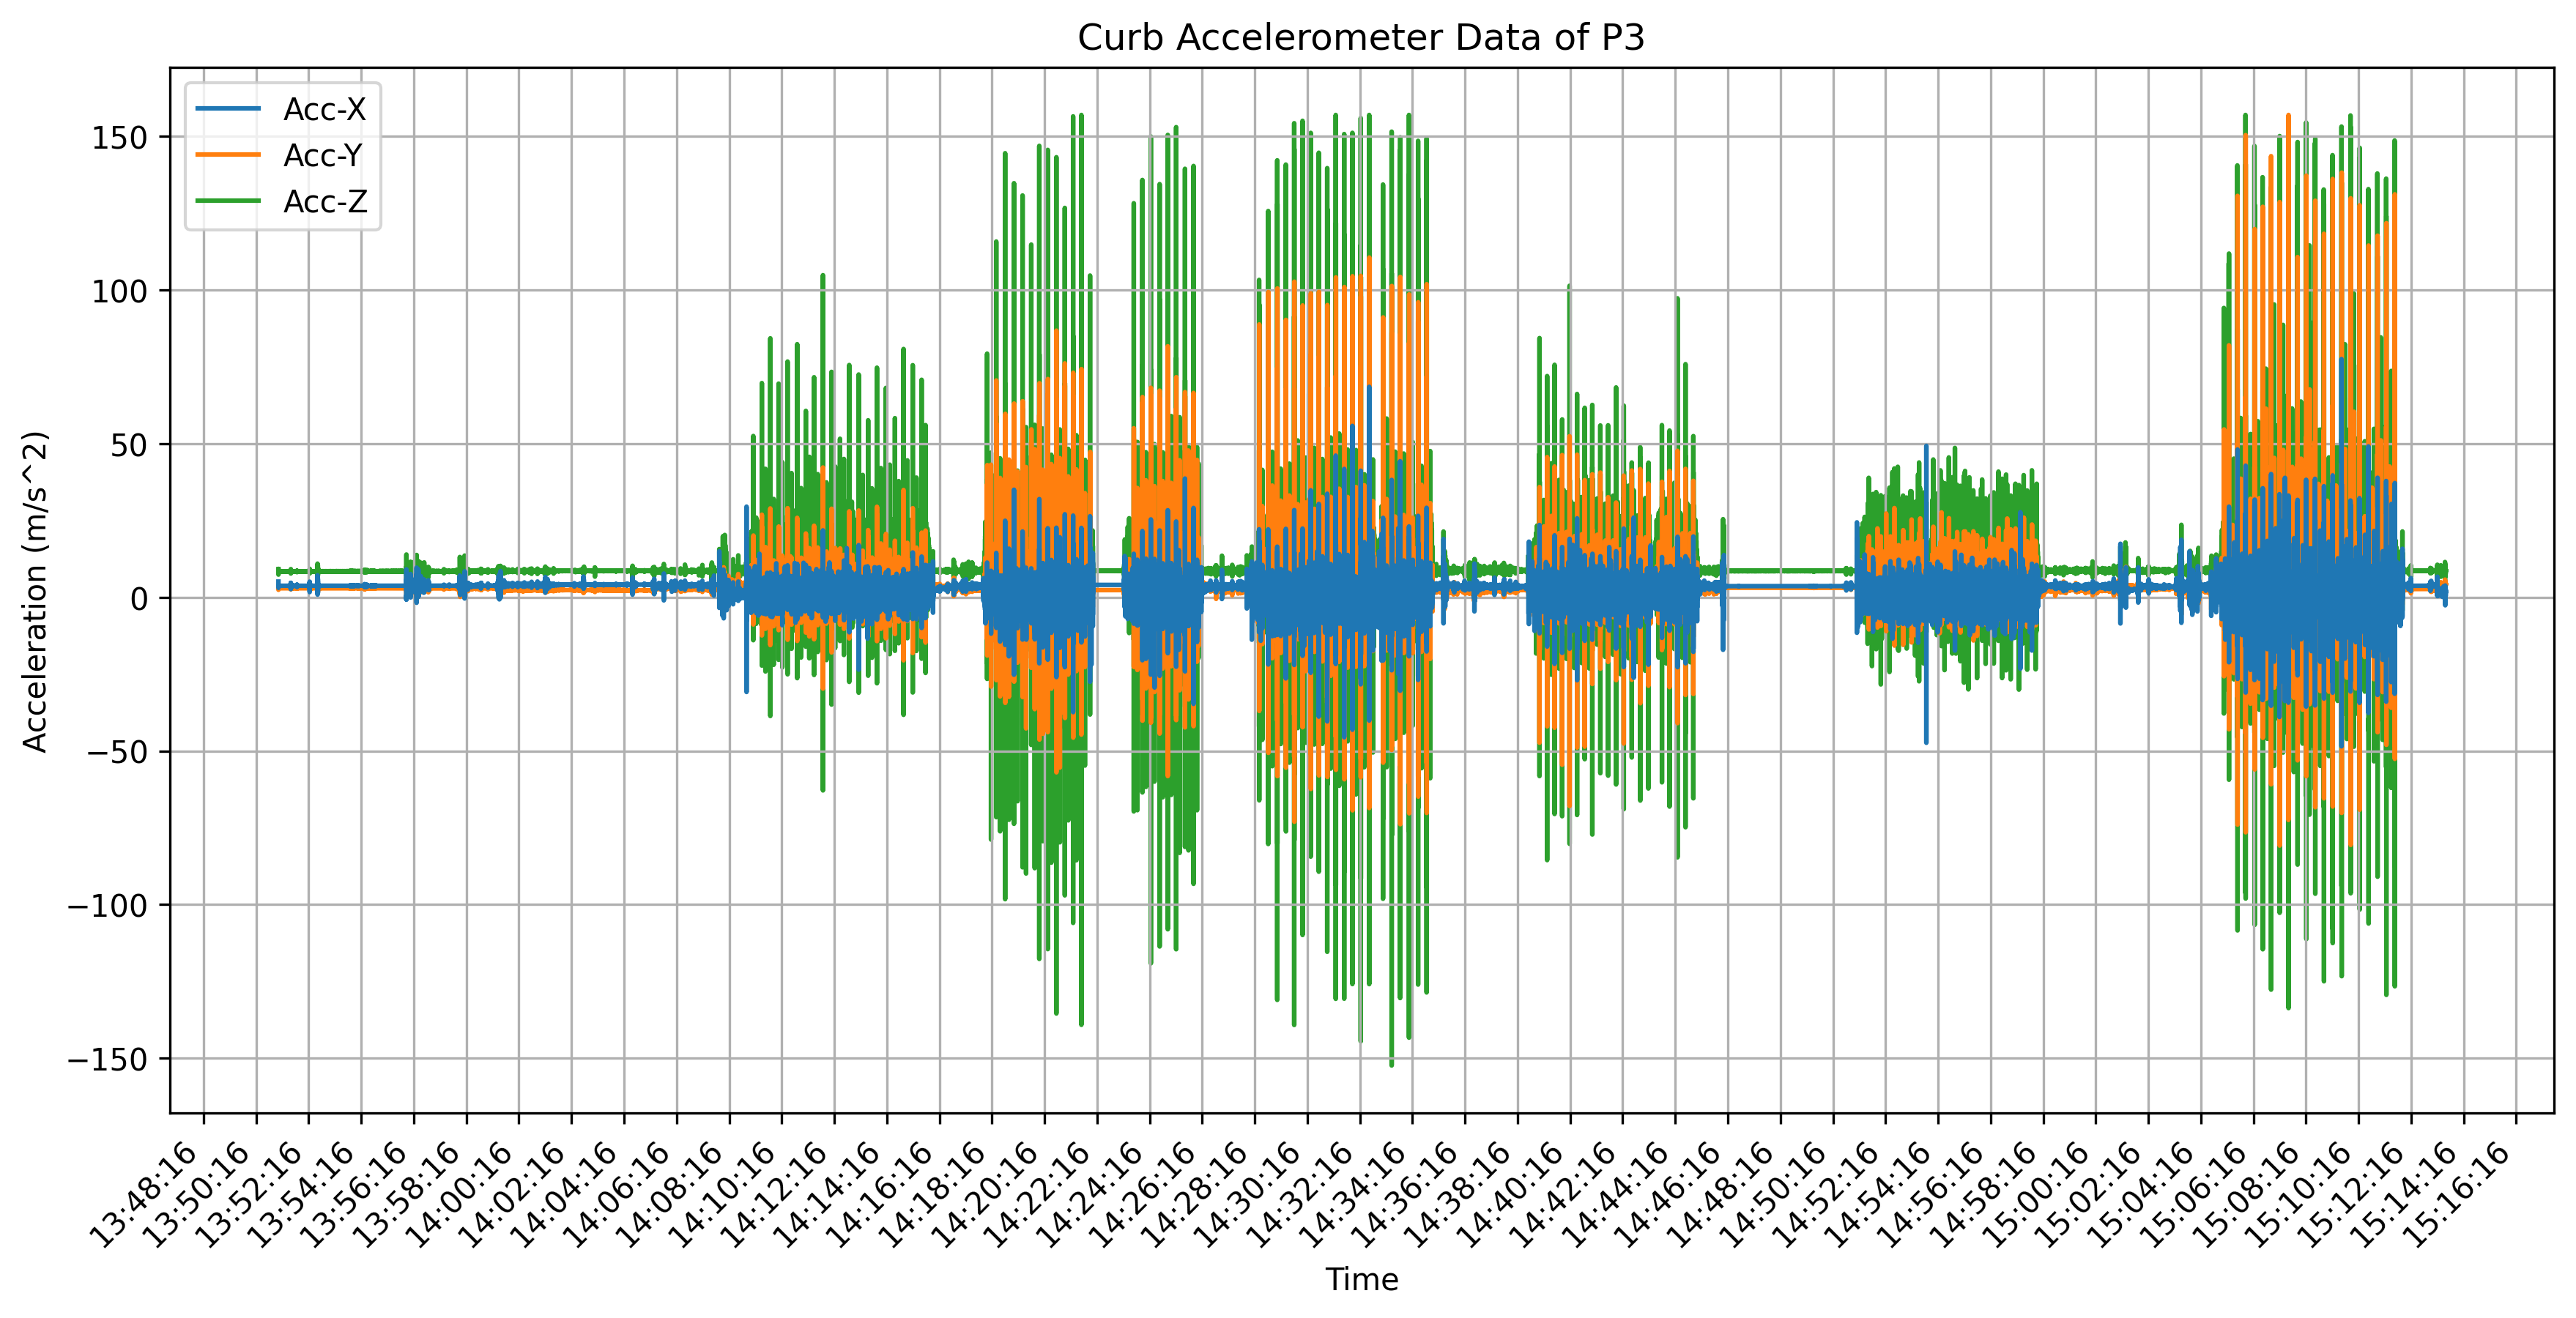

In [ ]:
df_three= pd.read_csv('../../data/Curb/P3/handlebar/Accelerometer/Accelerometer.0.csv')  
print_sampling_frequency(df_three, timestamp_col='NTP')
plot_accelerometer_data(df_three, name='Curb Accelerometer Data of P3')

,Unnamed: 0,NTP,Acc-X,Acc-Y,Acc-Z,Timestamp_unix,curb_activity,curb_scene,curb_height_down,curb_height_up,curb_type_down,curb_type_up,roughness
0,0,2024-07-24 10:26:01.863,1.417374,4.161118,8.762772,1.721817e+12,1.0,0.0,1.0,3.0,1.0,2.0,-1.0
1,1,2024-07-24 10:26:01.867,1.393433,4.161118,8.753204,1.721817e+12,1.0,0.0,1.0,3.0,1.0,2.0,-1.0
2,2,2024-07-24 10:26:01.872,1.407791,4.165909,8.762772,1.721817e+12,1.0,0.0,1.0,3.0,1.0,2.0,-1.0
3,3,2024-07-24 10:26:01.877,1.446091,4.170700,8.781937,1.721817e+12,1.0,0.0,1.0,3.0,1.0,2.0,-1.0
4,4,2024-07-24 10:26:01.884,1.417374,4.175491,8.753204,1.721817e+12,1.0,0.0,1.0,3.0,1.0,2.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
549206,549206,2024-07-24 11:11:20.851,3.806778,2.609680,8.777145,1.721819e+12,0.0,0.0,3.0,1.0,2.0,1.0,0.0
549207,549207,2024-07-24 11:11:20.857,3.758896,2.652771,8.681381,1.721819e+12,0.0,0.0,3.0,1.0,2.0,1.0,0.0
549208,549208,2024-07-24 11:11:20.866,3.763687,2.796432,8.370132,1.721819e+12,0.0,0.0,3.0,1.0,2.0,1.0,0.0
549209,549209,2024-07-24 11:11:20.870,3.734955,2.839523,8.307877,1.721819e+12,0.0,0.0,3.0,1.0,2.0,1.0,0.0


Sampling frequency: 201.44 Hz


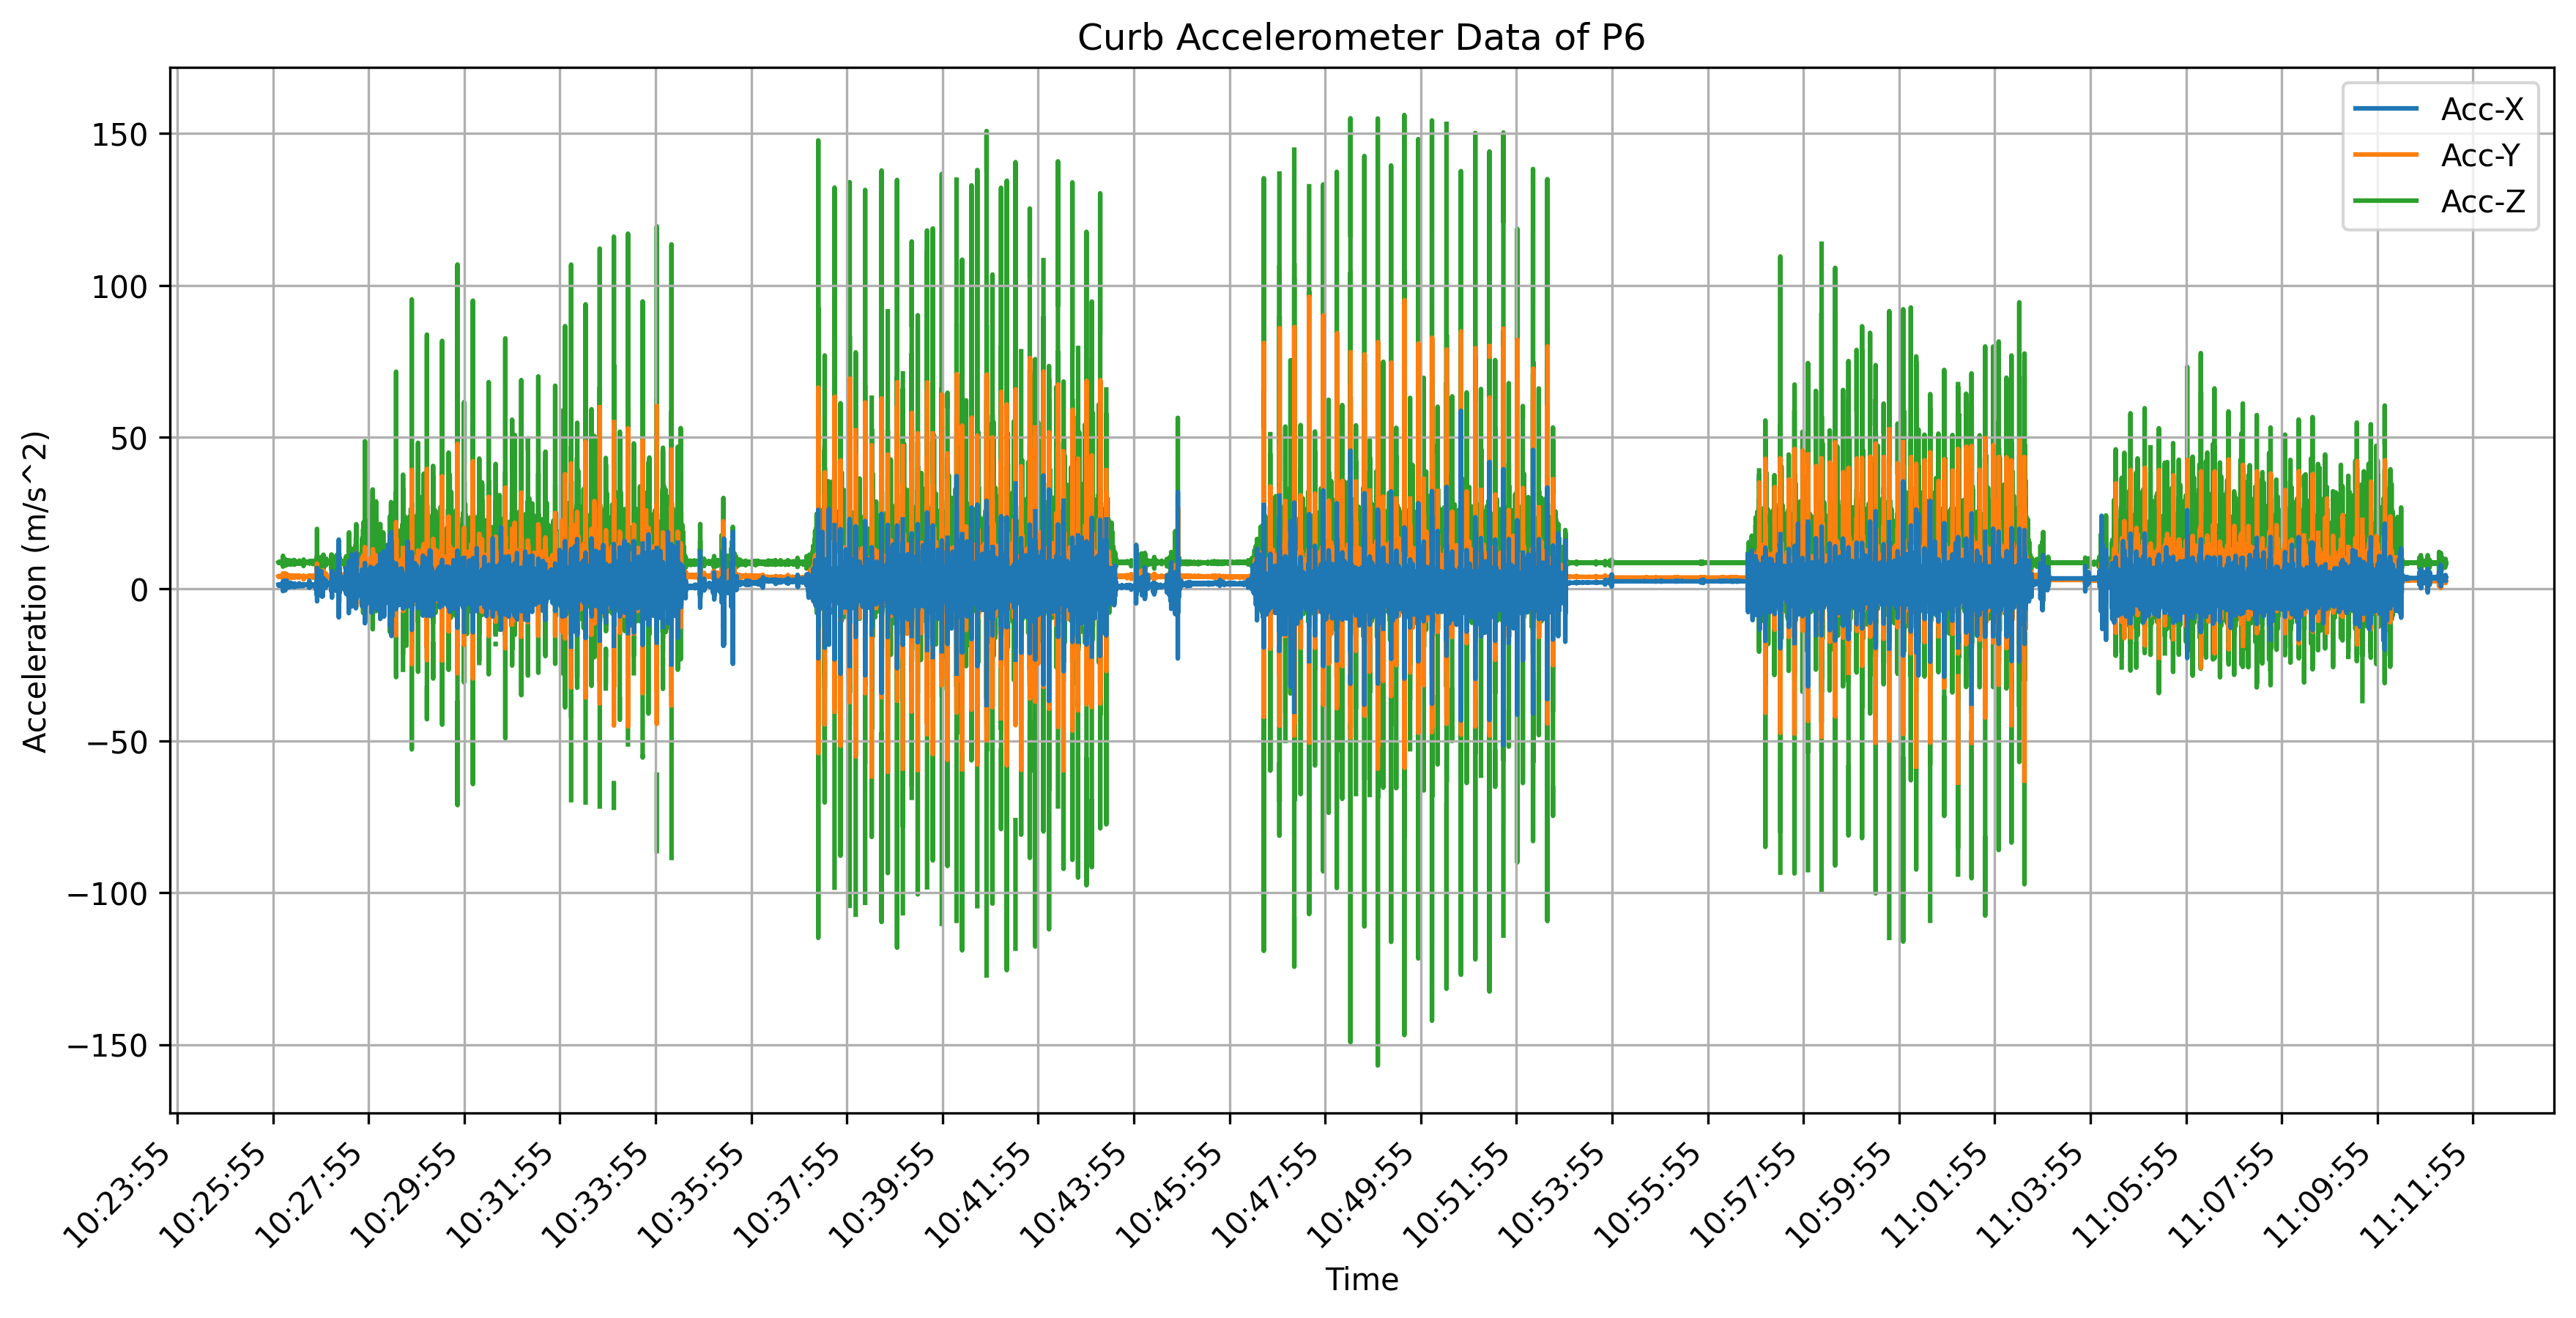

In [ ]:
# P6
df_P6 = pd.read_csv('../../data/Curb/P6/handlebar/Accelerometer/Accelerometer_data_merged_ESP1.csv')
print_sampling_frequency(df_P6, timestamp_col='NTP')
plot_accelerometer_data(df_P6, name='Curb Accelerometer Data of P6')

Sampling frequency: 201.36 Hz


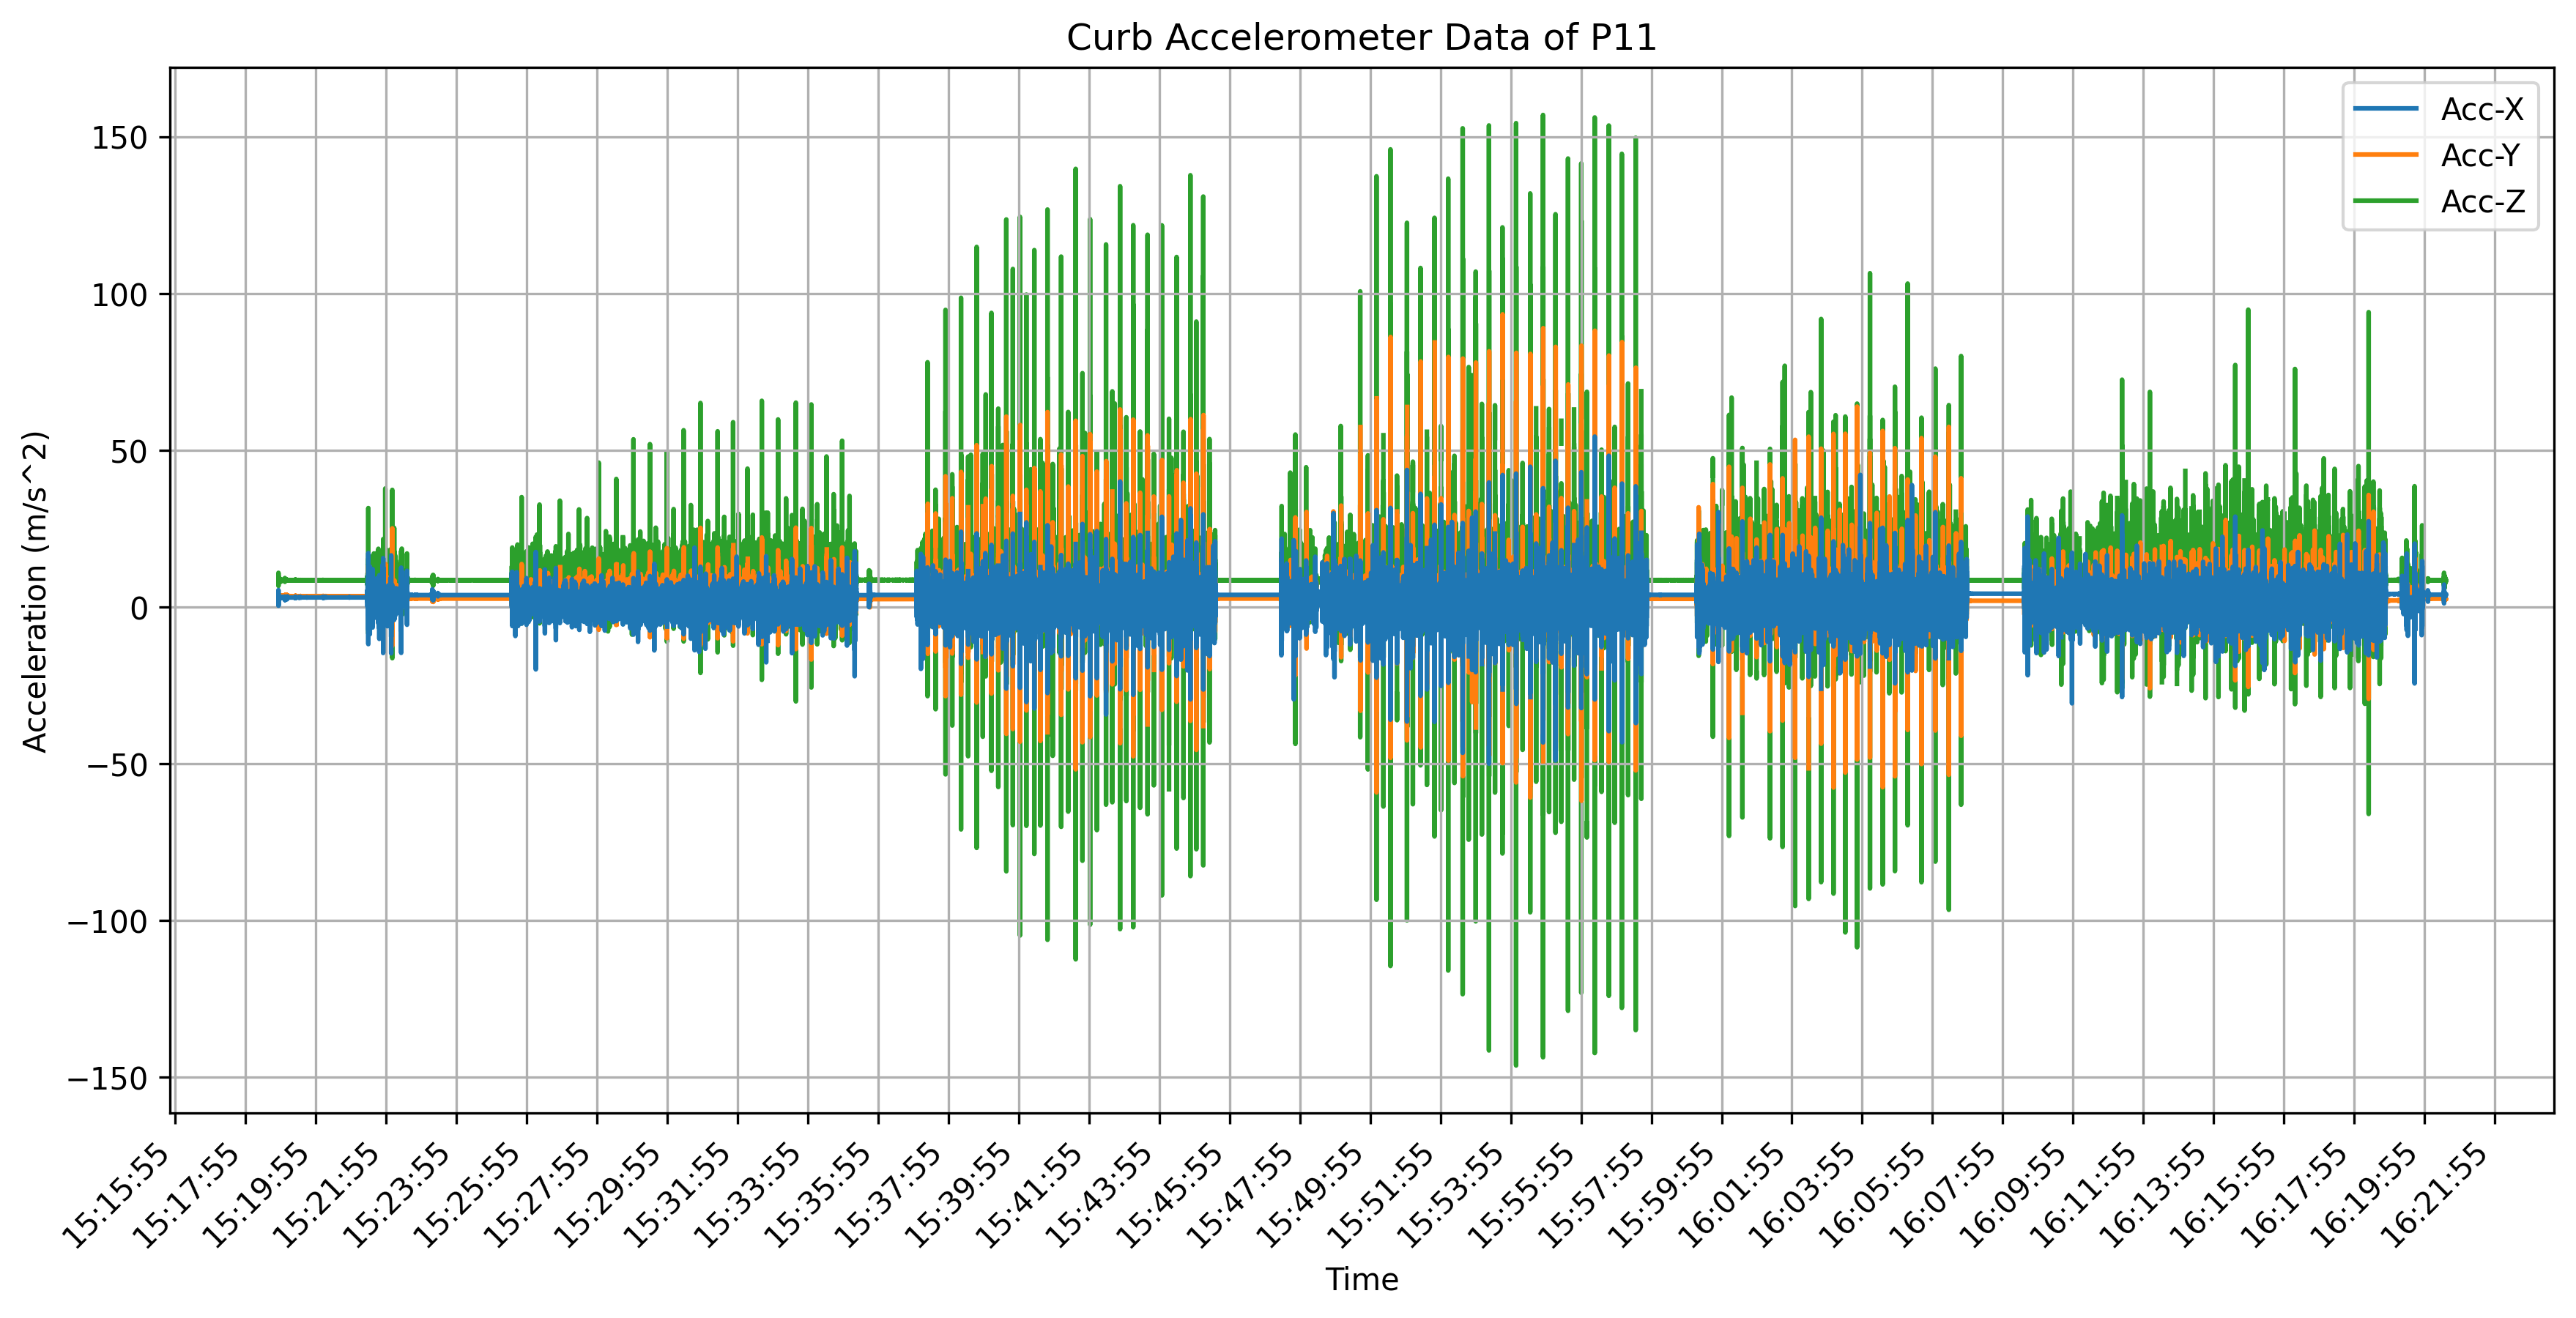

In [12]:
# P11
df_P11 = pd.read_csv('../../data/Curb/P11/handlebar/Accelerometer/Accelerometer_data_merged_ESP1.csv')
print_sampling_frequency(df_P11, timestamp_col='NTP')
plot_accelerometer_data(df_P11, name='Curb Accelerometer Data of P11')

## 2. Curb/Normal cycling segmentation

In [3]:
df_P6 = pd.read_csv('../../data/Curb/P6/handlebar/Accelerometer/Accelerometer_data_combined.csv')
df_P6


,Unnamed: 0,NTP,Acc-X,Acc-Y,Acc-Z,Timestamp_unix,curb_activity,curb_scene,curb_height_down,curb_height_up,curb_type_down,curb_type_up,roughness
0,0,2024-07-24 10:26:01.863,1.417374,4.161118,8.762772,1.721817e+12,1.0,0.0,1.0,3.0,1.0,2.0,-1.0
1,1,2024-07-24 10:26:01.867,1.393433,4.161118,8.753204,1.721817e+12,1.0,0.0,1.0,3.0,1.0,2.0,-1.0
2,2,2024-07-24 10:26:01.872,1.407791,4.165909,8.762772,1.721817e+12,1.0,0.0,1.0,3.0,1.0,2.0,-1.0
3,3,2024-07-24 10:26:01.877,1.446091,4.170700,8.781937,1.721817e+12,1.0,0.0,1.0,3.0,1.0,2.0,-1.0
4,4,2024-07-24 10:26:01.884,1.417374,4.175491,8.753204,1.721817e+12,1.0,0.0,1.0,3.0,1.0,2.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
186630,549101,2024-07-24 11:11:20.851,3.806778,2.609680,8.777145,1.721819e+12,1.0,0.0,3.0,1.0,2.0,1.0,0.0
186631,549102,2024-07-24 11:11:20.857,3.758896,2.652771,8.681381,1.721819e+12,1.0,0.0,3.0,1.0,2.0,1.0,0.0
186632,549103,2024-07-24 11:11:20.866,3.763687,2.796432,8.370132,1.721819e+12,1.0,0.0,3.0,1.0,2.0,1.0,0.0
186633,549104,2024-07-24 11:11:20.870,3.734955,2.839523,8.307877,1.721819e+12,1.0,0.0,3.0,1.0,2.0,1.0,0.0


In [4]:
curb_crossing = df_P6[df_P6['curb_scene'] == 1.0]
normal_crossing = df_P6[df_P6['curb_scene'] == 0.0]
print(f"Curb crossing samples: {len(curb_crossing)}, Normal crossing samples: {len(normal_crossing)}")

Curb crossing samples: 9522, Normal crossing samples: 177113


## 3.1s windows

In [5]:
# Convert NTP timestamps to datetime and segment data
df_P6['timestamp'] = pd.to_datetime(df_P6['NTP'])

# Segment data for both activities using the updated 's' parameter
curb_segments = [g for _, g in df_P6[df_P6['curb_scene'] == 1.0].groupby(df_P6['timestamp'].dt.floor('1s'))]
normal_segments = [g for _, g in df_P6[df_P6['curb_scene'] == 0.0].groupby(df_P6['timestamp'].dt.floor('1s'))]

# Print summary
print(f"Number of curb crossing segments: {len(curb_segments)}")
print(f"Number of normal segments: {len(normal_segments)}")

Number of curb crossing segments: 139
Number of normal segments: 983


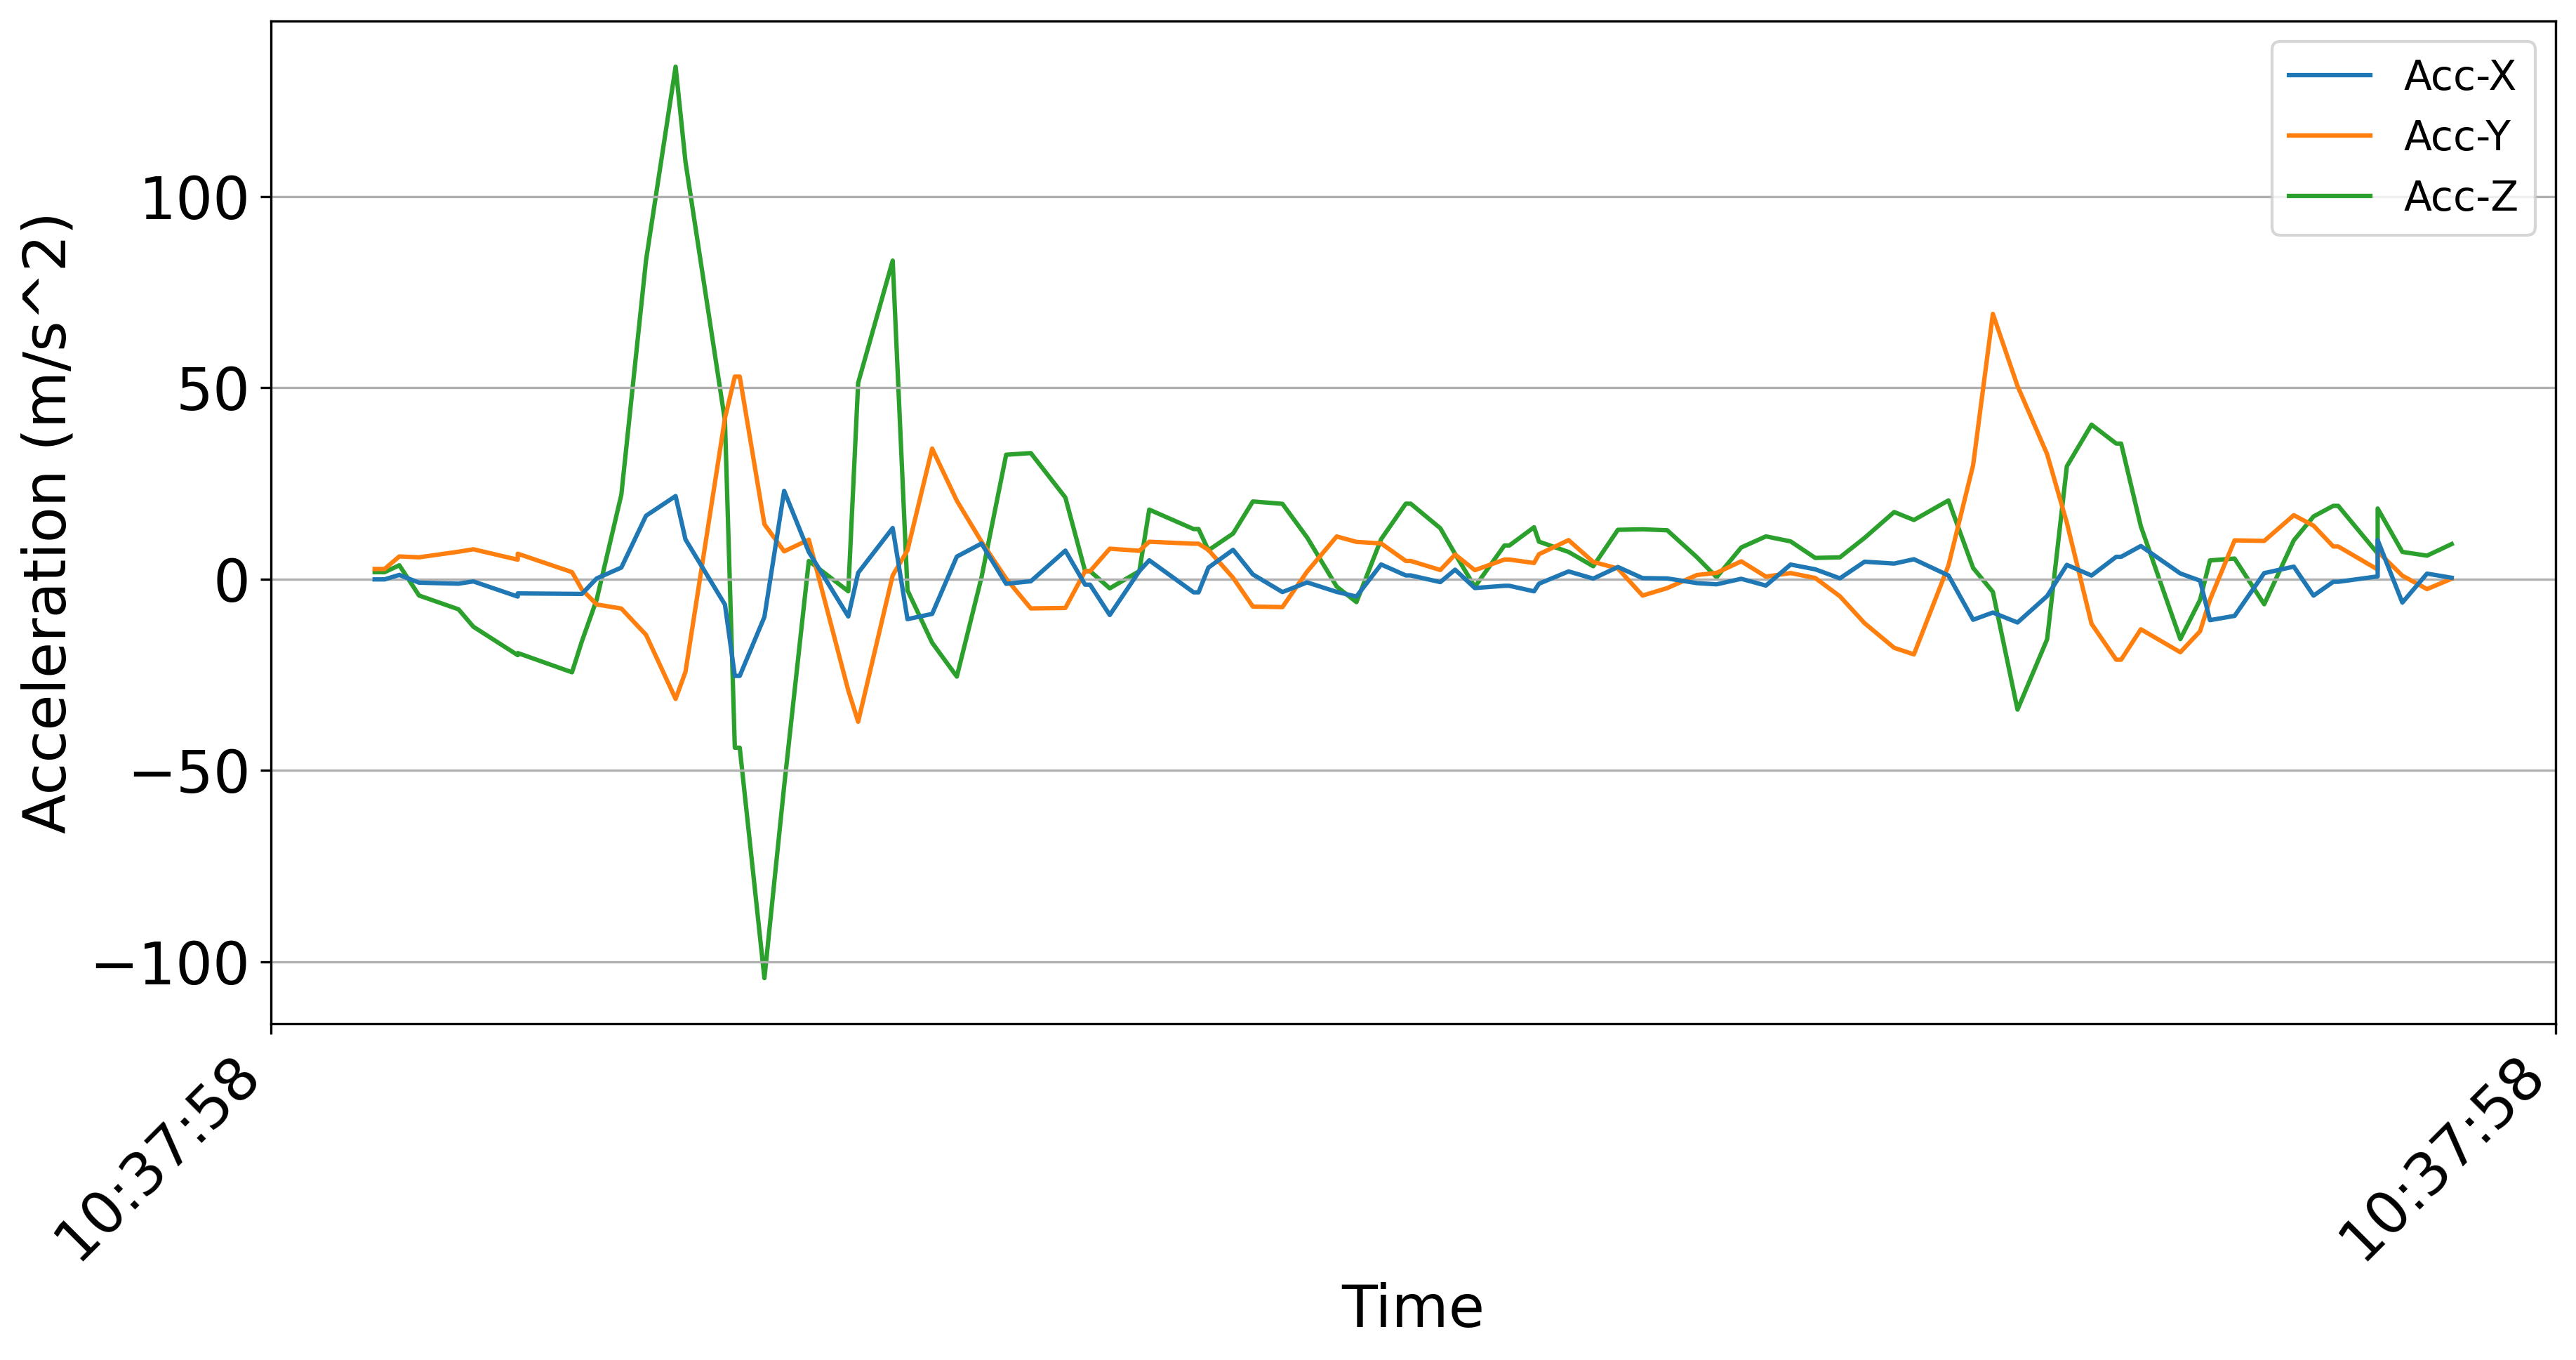

In [6]:
plot_accelerometer_data_bachelorarbeit(curb_segments[30])


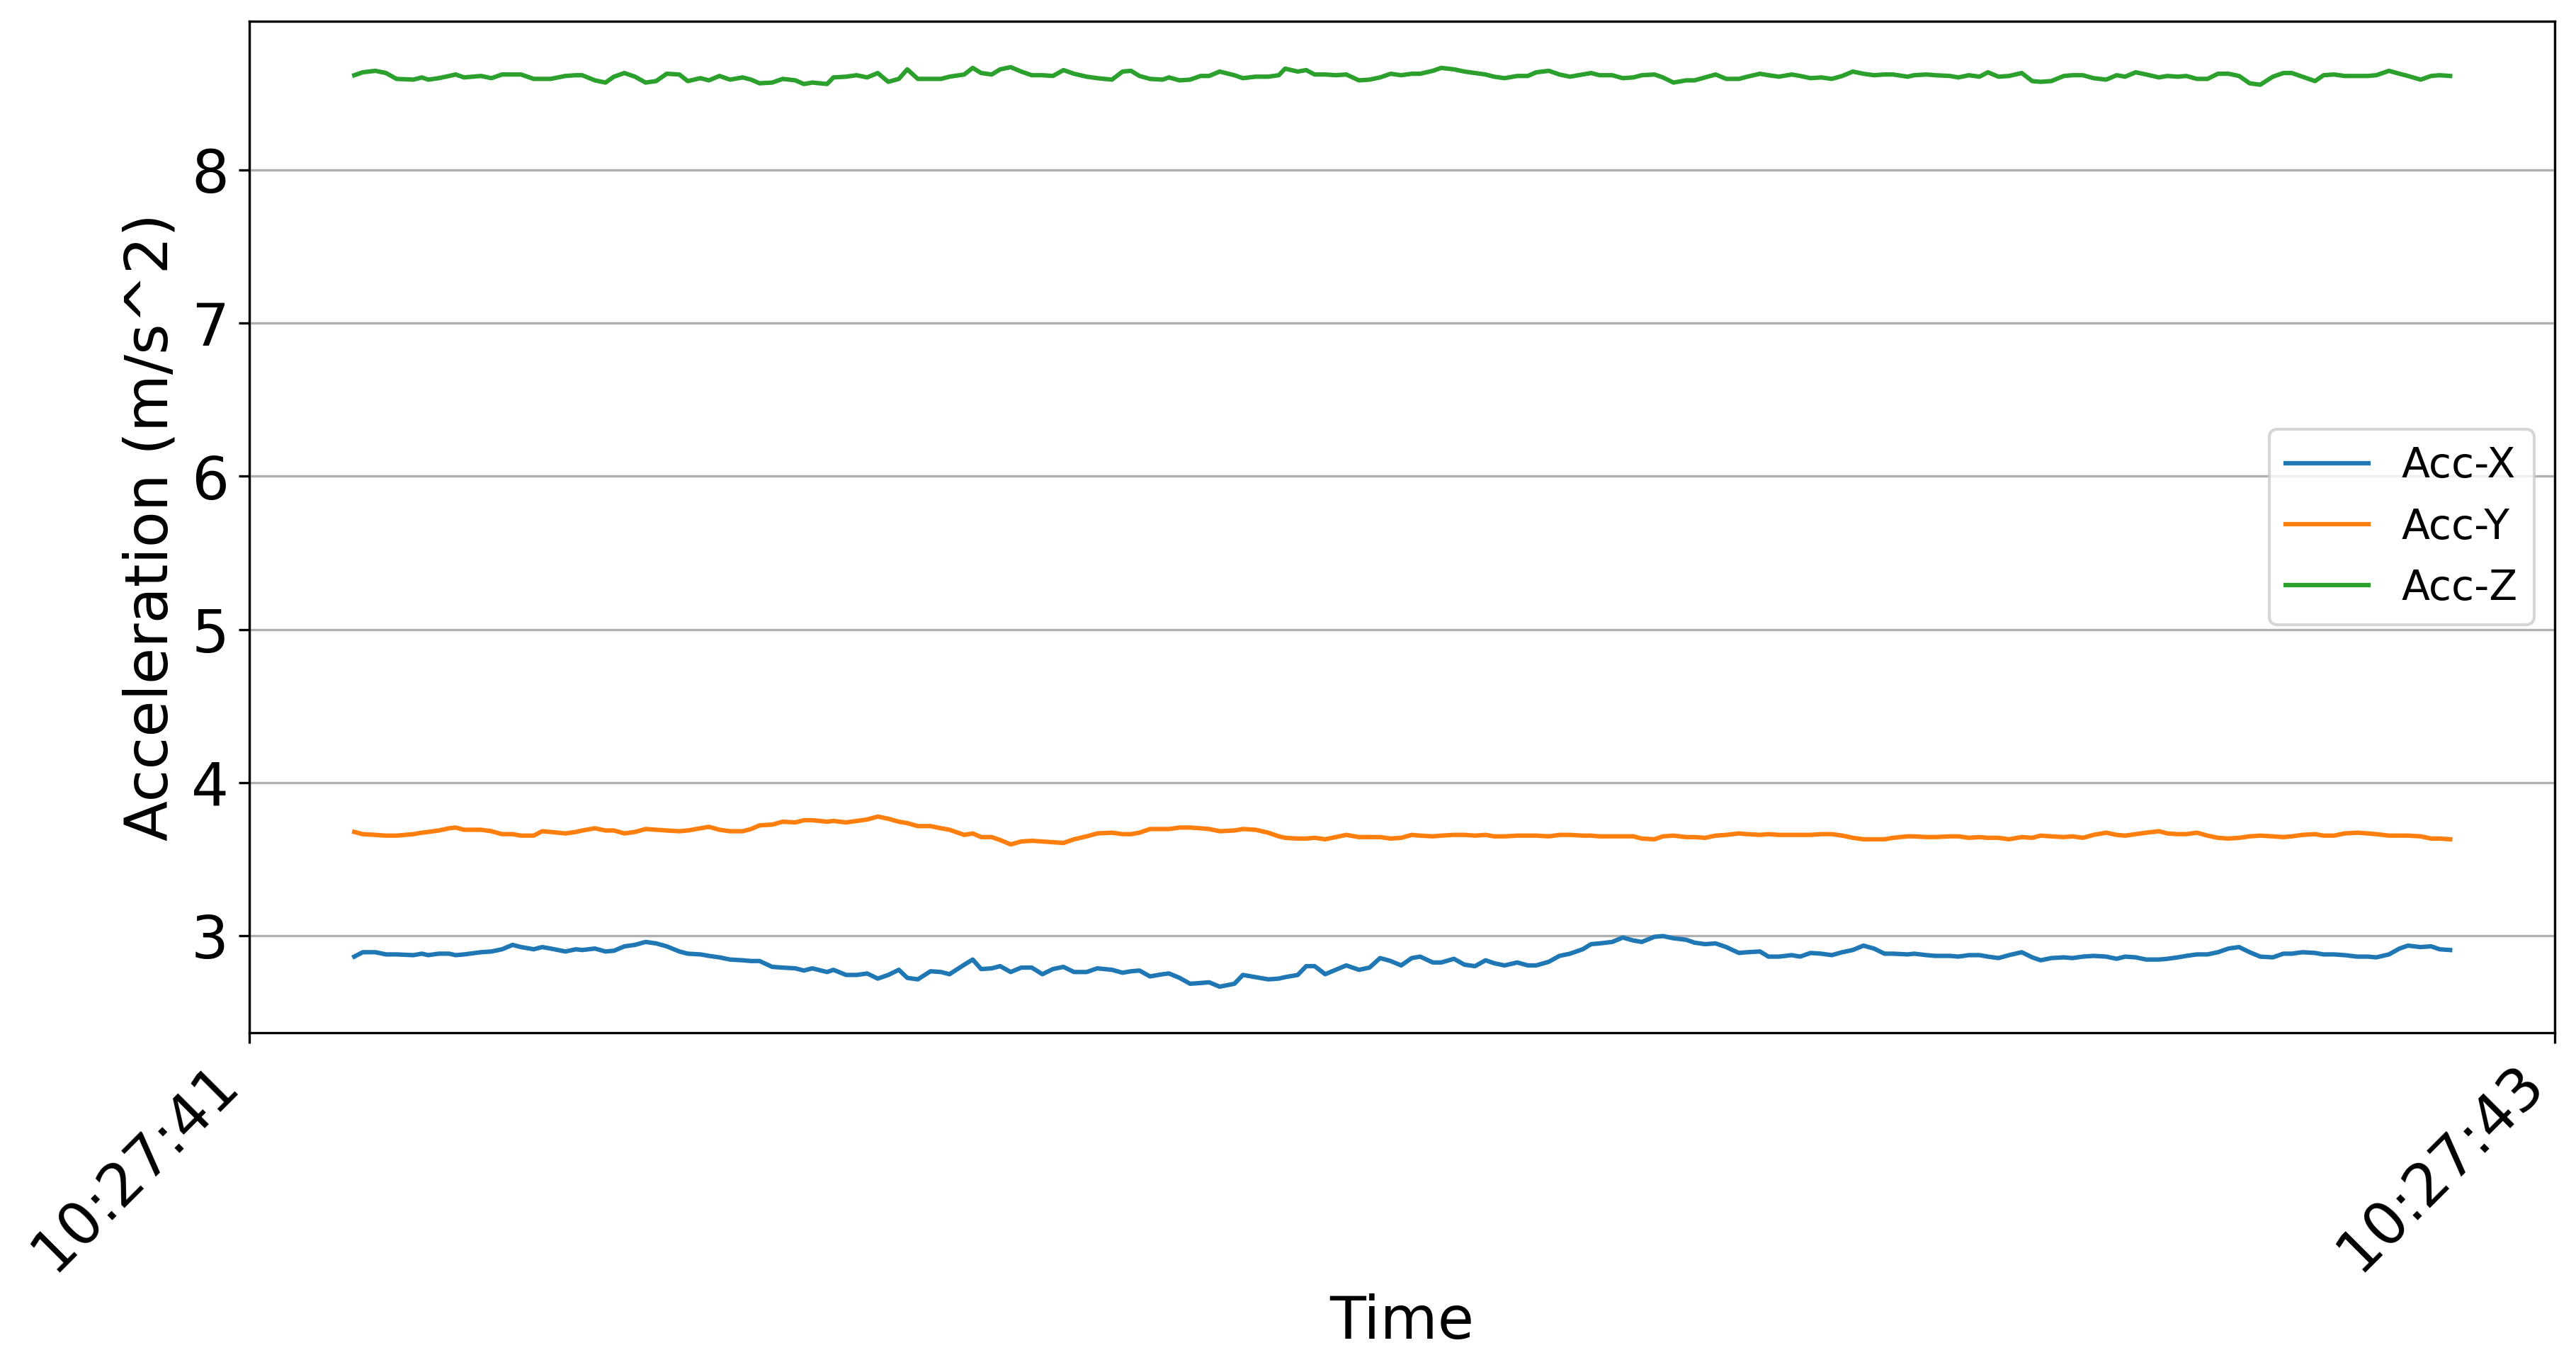

In [7]:
plot_accelerometer_data_bachelorarbeit(normal_segments[101])

In [9]:
# Segment data for both activities using the updated 's' parameter
curb_segments_half = [g for _, g in df_P6[df_P6['curb_scene'] == 1.0].groupby(df_P6['timestamp'].dt.floor('0.5s'))]
normal_segments_half = [g for _, g in df_P6[df_P6['curb_scene'] == 0.0].groupby(df_P6['timestamp'].dt.floor('0.5s'))]

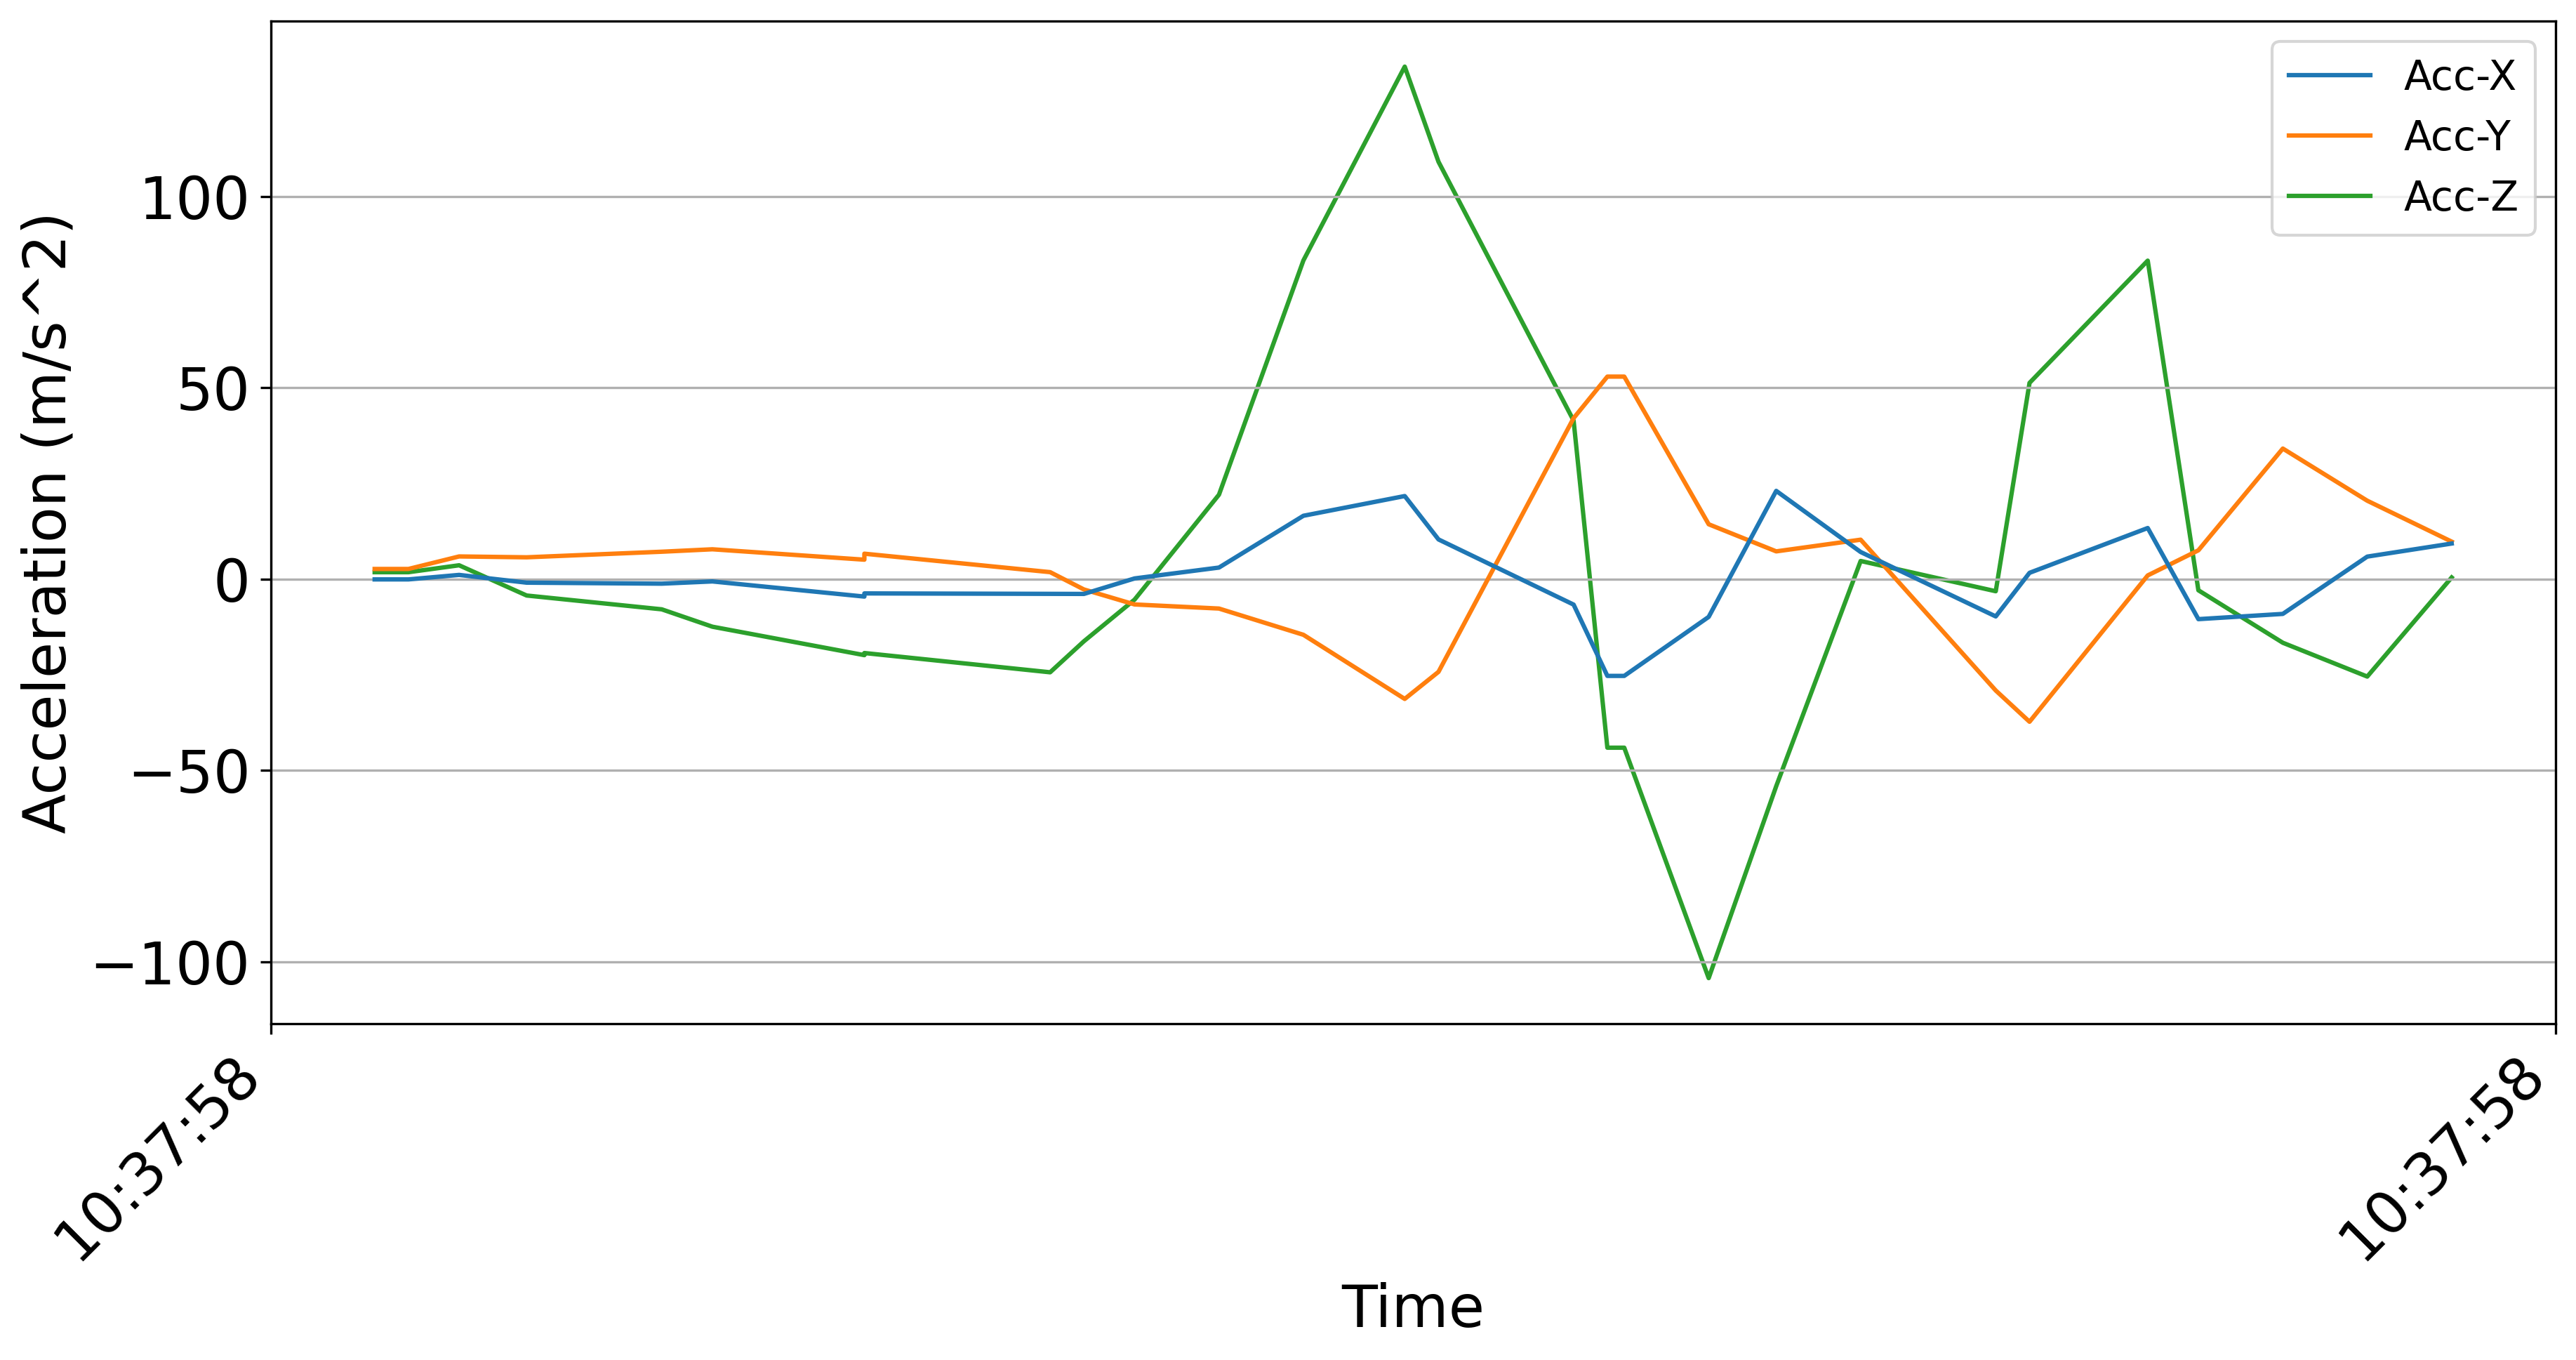

In [12]:
plot_accelerometer_data_bachelorarbeit(curb_segments_half[42])

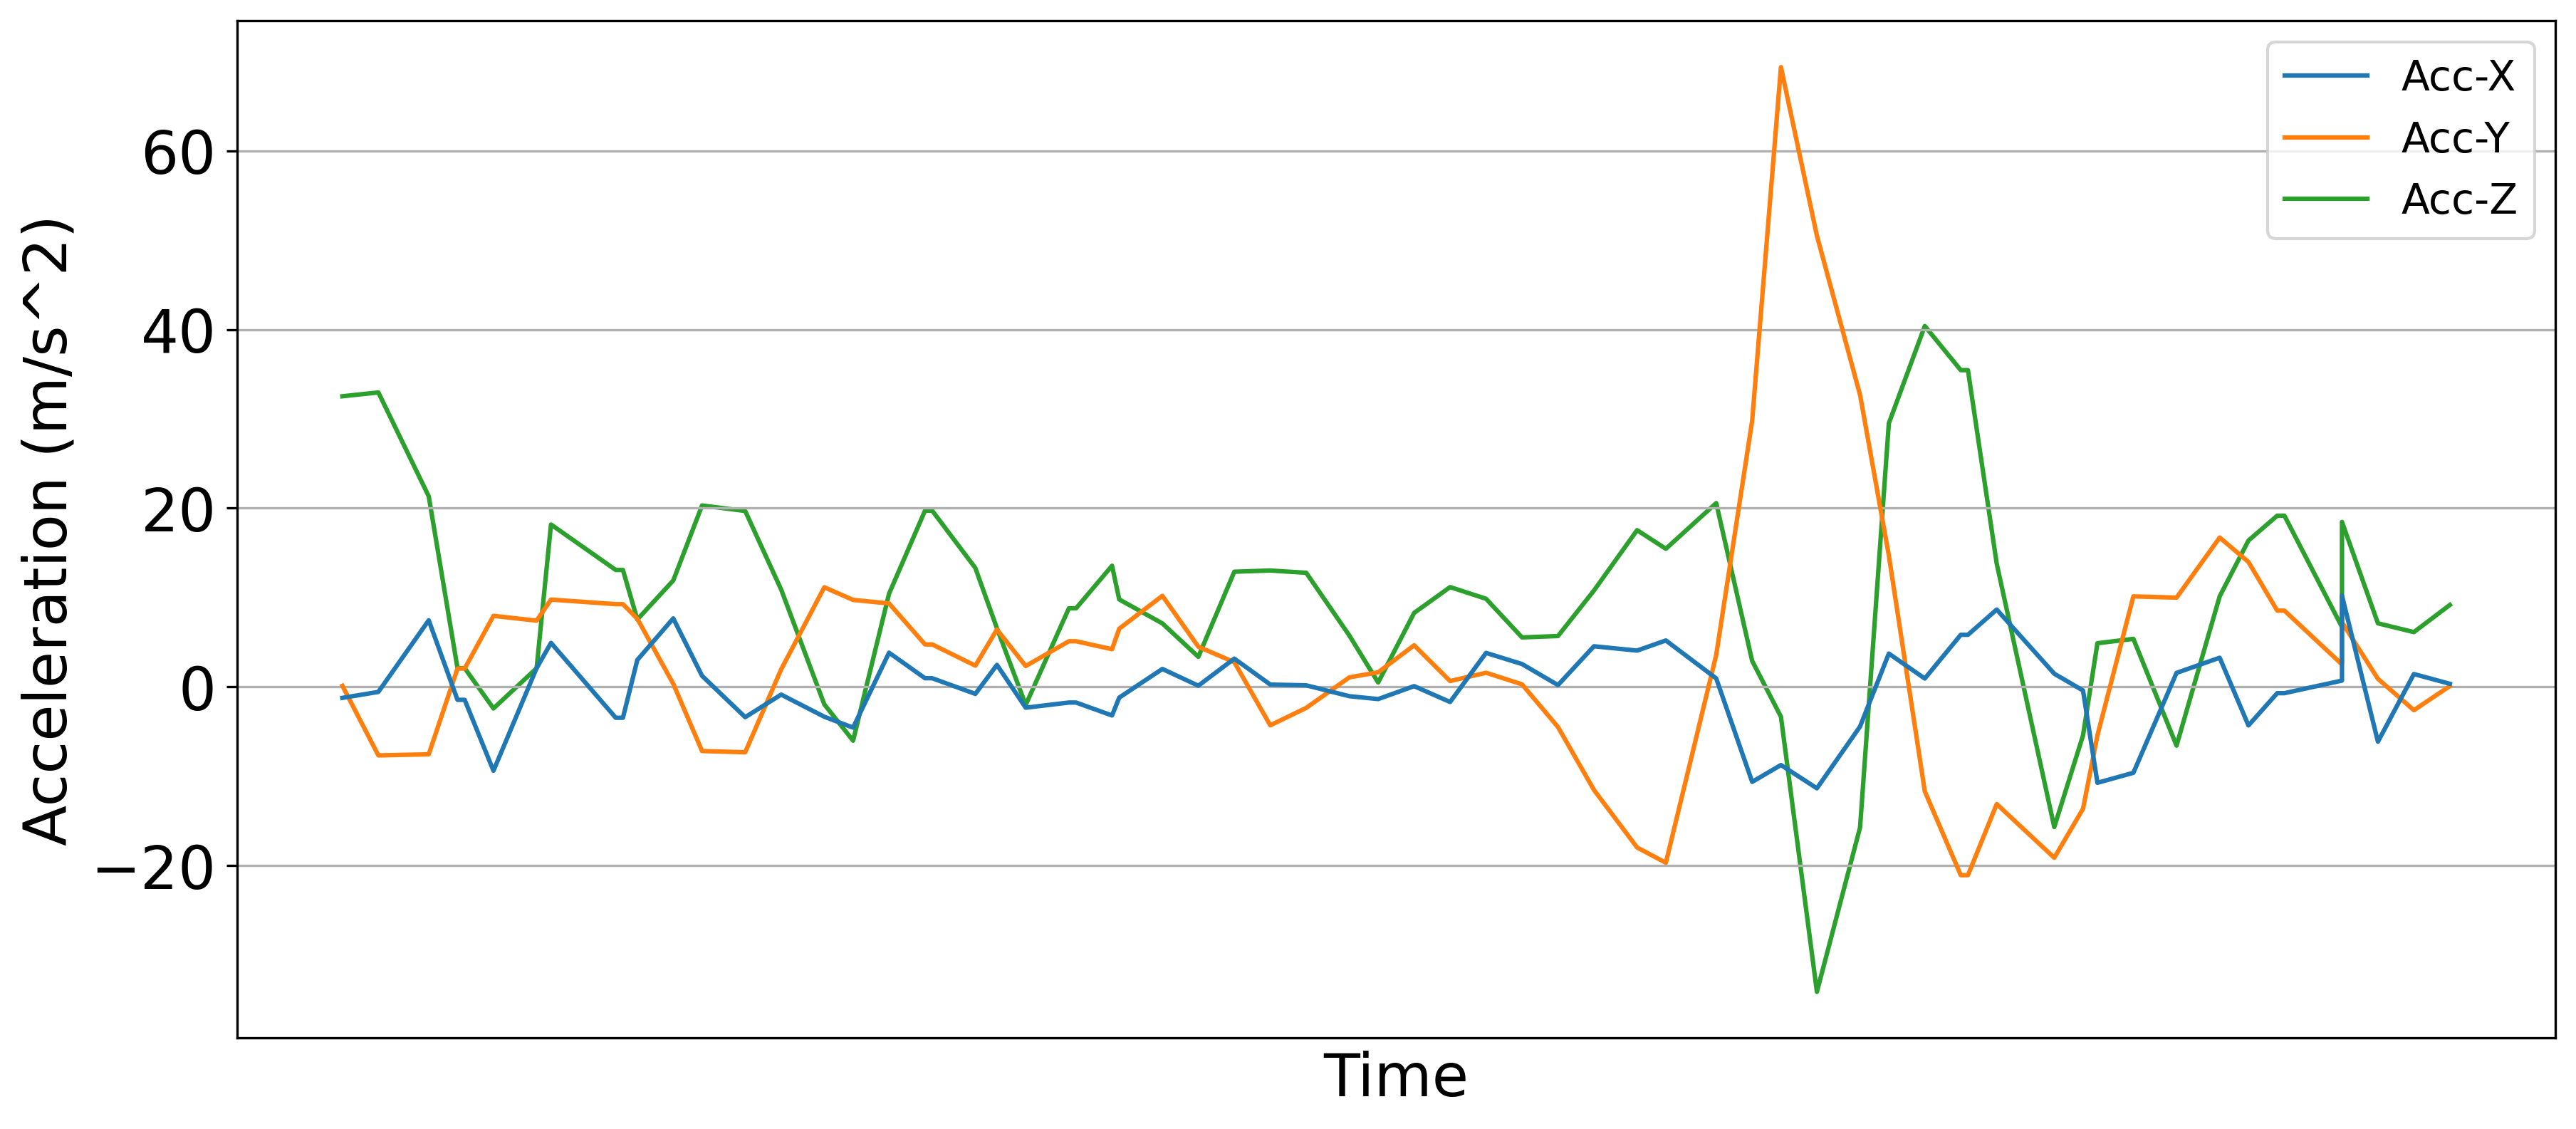

In [10]:
plot_accelerometer_data_bachelorarbeit(curb_segments_half[43])


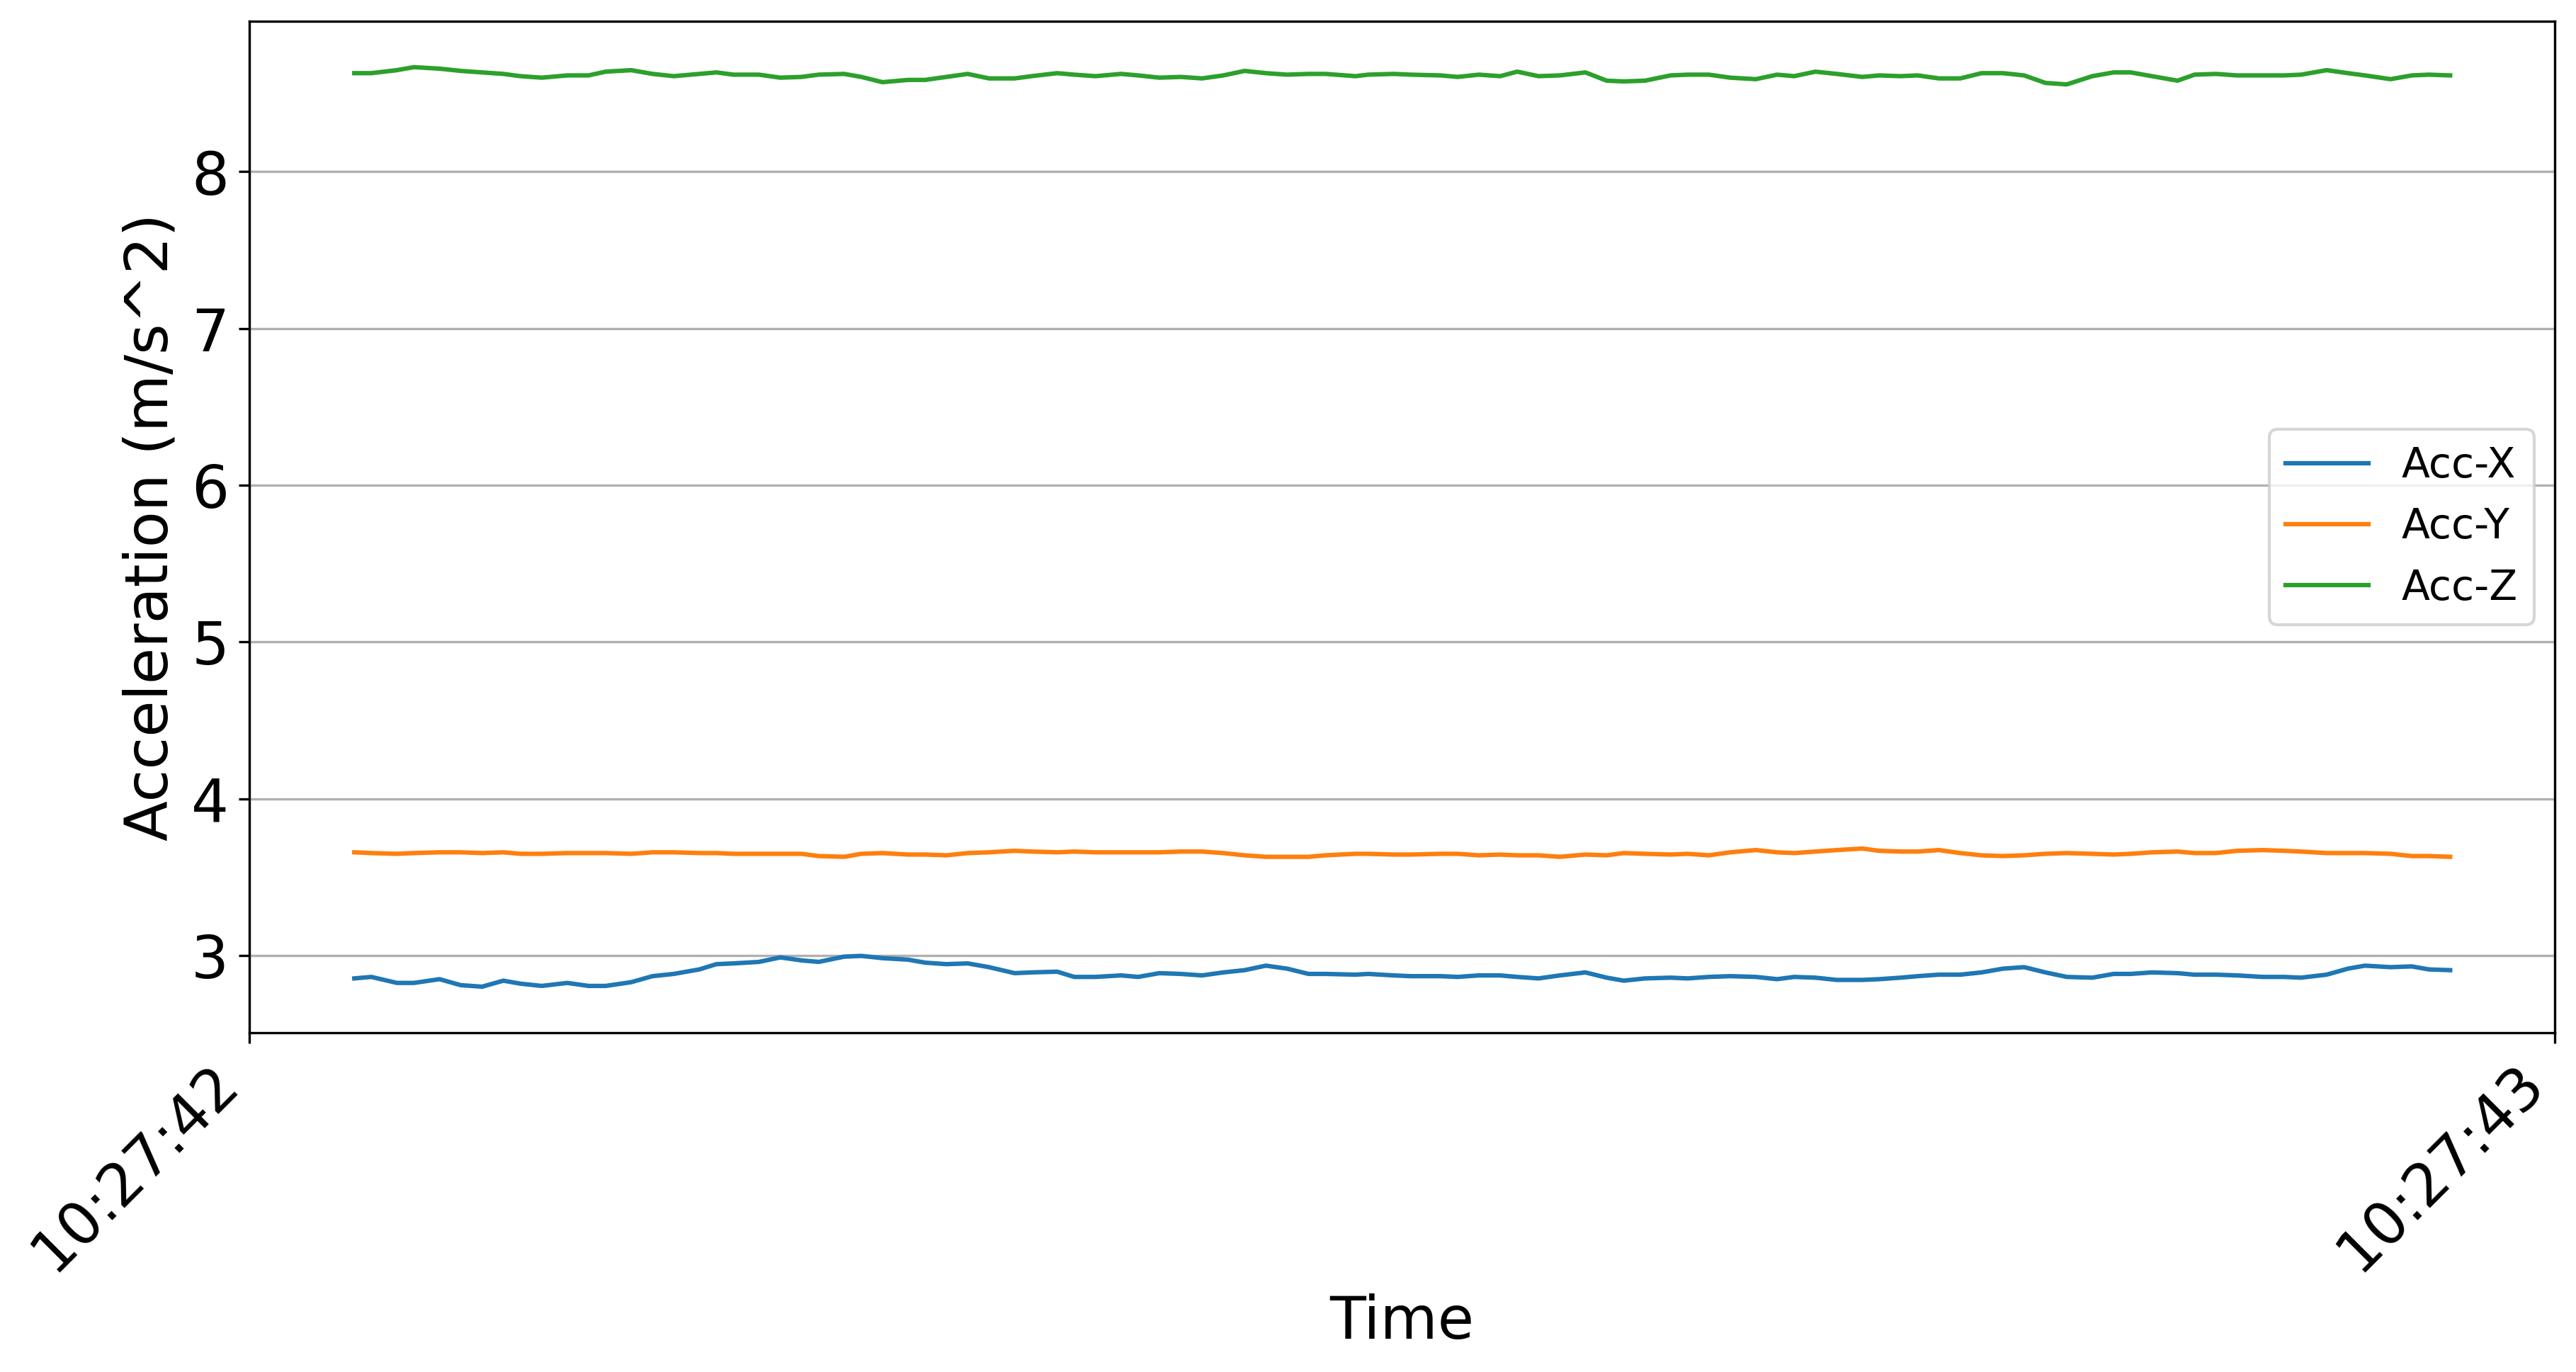

In [11]:
plot_accelerometer_data_bachelorarbeit(normal_segments_half[202])